In [1]:
import torch
import numpy as np
import networkx as nx

import matplotlib.pyplot as plt

In [2]:
from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures

# Import dataset from PyTorch Geometric
dataset = Planetoid(root='data/Planetoid', name='Cora', transform=NormalizeFeatures())

# Print information
print(dataset)
print('------------')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

# Print first element
print(f'Graph: {dataset[0]}')

/home/filipe/miniconda3/envs/redes_grafos/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Cora()
------------
Number of graphs: 1
Number of features: 1433
Number of classes: 7
Graph: Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])


In [3]:
data = dataset[0]

print(f'x = {data.x.shape}')
print(data.x)

x = torch.Size([2708, 1433])
tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])


In [4]:
print(f'edge_index = {data.edge_index.shape}')
print(data.edge_index)

edge_index = torch.Size([2, 10556])
tensor([[ 633, 1862, 2582,  ...,  598, 1473, 2706],
        [   0,    0,    0,  ..., 2707, 2707, 2707]])


In [5]:
from torch_geometric.utils import to_dense_adj

A = to_dense_adj(data.edge_index)[0].numpy().astype(int)
print(f'A = {A.shape}')
print(A)

A = (2708, 2708)
[[0 0 0 ... 0 0 0]
 [0 0 1 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 1]
 [0 0 0 ... 0 1 0]]


In [6]:
print(f'y = {data.y.shape}')
print(data.y)

y = torch.Size([2708])
tensor([3, 4, 4,  ..., 3, 3, 3])


In [7]:
print(f'train_mask = {data.train_mask.shape}')
print(data.train_mask)

train_mask = torch.Size([2708])
tensor([ True,  True,  True,  ..., False, False, False])


In [8]:
print(f'Edges are directed: {data.is_directed()}')
print(f'Graph has isolated nodes: {data.has_isolated_nodes()}')
print(f'Graph has loops: {data.has_self_loops()}')

Edges are directed: False
Graph has isolated nodes: False
Graph has loops: False


In [16]:
adj

tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 1.,  ..., 0., 0., 0.],
         [0., 1., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 1.],
         [0., 0., 0.,  ..., 0., 1., 0.]]])

In [125]:
from torch_geometric.nn import DenseGCNConv
from torch.nn import Linear
import torch.nn as nn
import torch.nn.functional as F



x_dense = data.x.unsqueeze(0)
adj_orig = to_dense_adj(data.edge_index)


class GCN(torch.nn.Module):
    def __init__(self, adj):
        super().__init__()
        self.adj_param = adj 
        # self.adj_param = nn.Parameter(adj.clone().float())
        
        self.gcn1 = DenseGCNConv(dataset.num_features, 16) 
        self.gcn2 = DenseGCNConv(16, dataset.num_classes)

    def normalize_adj(self, adj):
        eye = torch.eye(adj.size(-1), device=adj.device).unsqueeze(0)
        adj_hat = adj + eye
        deg = adj_hat.sum(dim=-1)
        deg_inv_sqrt = deg.pow(-0.5)
        deg_inv_sqrt.masked_fill_(deg_inv_sqrt == float('inf'), 0)
        return deg_inv_sqrt.unsqueeze(-1) * adj_hat * deg_inv_sqrt.unsqueeze(1)
    
    def forward(self, x):
        adj_positive = self.adj_param
        # adj_positive = F.sigmoid(self.adj_param)
        # adj_positive = F.relu(self.adj_param) # F.softmax(self.adj_param, dim=-1)
        # adj_positive = gumbel_sigmoid(self.adj_param)
        
        adj_norm = self.normalize_adj(adj_positive)
        
        x = self.gcn1(x, adj_norm, add_loop=False)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.gcn2(x, adj_norm, add_loop=False)
        
        return x

model = GCN(adj_orig)
print(model)
for name, param in model.named_parameters():
    print(f"Camada: {name}")
    print(f"Tamanho (Shape): {param.shape}")
    print(f"Valores:\n{param}\n")

GCN(
  (gcn1): DenseGCNConv(1433, 16)
  (gcn2): DenseGCNConv(16, 7)
)
Camada: gcn1.bias
Tamanho (Shape): torch.Size([16])
Valores:
Parameter containing:
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       requires_grad=True)

Camada: gcn1.lin.weight
Tamanho (Shape): torch.Size([16, 1433])
Valores:
Parameter containing:
tensor([[ 0.0293, -0.0440, -0.0609,  ...,  0.0475, -0.0629, -0.0064],
        [ 0.0090, -0.0407, -0.0306,  ..., -0.0266,  0.0300,  0.0137],
        [-0.0105,  0.0298, -0.0609,  ...,  0.0632,  0.0563,  0.0083],
        ...,
        [ 0.0630, -0.0586, -0.0371,  ..., -0.0090,  0.0304, -0.0520],
        [ 0.0296, -0.0333,  0.0359,  ..., -0.0361, -0.0258, -0.0234],
        [ 0.0486, -0.0593,  0.0631,  ...,  0.0160, -0.0546, -0.0418]],
       requires_grad=True)

Camada: gcn2.bias
Tamanho (Shape): torch.Size([7])
Valores:
Parameter containing:
tensor([0., 0., 0., 0., 0., 0., 0.], requires_grad=True)

Camada: gcn2.lin.weight
Tamanho (Shape): torch.Si

In [126]:

# Calculate accuracy
def accuracy(pred_y, y):
    return (pred_y == y).sum() / len(y)

def train(model,optimizer,criterion):# Training loop
    
    model.train()
    
    # Clear gradients
    optimizer.zero_grad()

    # Forward pass
    out = model(x_dense)
    out = out.squeeze(0)
    # Calculate loss function
    loss = criterion(out[data.train_mask], data.y[data.train_mask]) 
    
    # Calculate accuracy
    acc = accuracy(out.argmax(dim=1)[data.train_mask], data.y[data.train_mask])

    
    # Compute gradients
    loss.backward()

    # Tune parameters
    optimizer.step()

    return loss.item(), acc.item()

def evaluate(model,criterion):# Validation loop
    model.eval() 
    with torch.no_grad(): 
        out_val = model(x_dense)
        out_val = out_val.squeeze(0)
        val_loss = criterion(out_val[data.val_mask], data.y[data.val_mask])
        out_val = out_val.argmax(dim=1)
        val_correct = out_val[data.val_mask] == data.y[data.val_mask]
        val_acc = int(val_correct.sum()) / int(data.val_mask.sum())
    return val_loss.item(),val_acc


In [ ]:
import copy

N_EPOCHS = 160 # 250
N_GENERATIONS = 100

adj_g0 = adj_orig.clone()
adj_gi = adj_orig.clone()

best_performance = -np.inf

for gen_idx in range(N_GENERATIONS):
    adj_gi_mut = adj_gi.clone()
    
    if gen_idx > 0:  # para avaliar a matriz original sem mutação na primeira geração
        # mutacao da matriz de adjacencia
        n_mudancas = np.random.randint(1, int(0.1 * adj_gi_mut.size(1)))
        for _ in range(n_mudancas):
            i, j = np.random.randint(0, adj_gi_mut.size(1), size=2)
            adj_gi_mut[0, i, j] = 1 - adj_gi_mut[0, i, j]  # Flip the edge (add/remove)
            adj_gi_mut[0, j, i] = 1 - adj_gi_mut[0, j, i]  # Flip the edge (add/remove)

    model_gcn = GCN(adj_gi_mut)

    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model_gcn.parameters(), lr=0.005) #,weight_decay=5e-4)

    train_losses = []
    val_losses = []

    best_val_loss = float('inf')
    best_val_acc = 0.0
    best_epoch = 0
    best_weights = None 

    val_accs = []

    for epoch in range(N_EPOCHS):
        loss , acc = train(model_gcn, optimizer, criterion)
        
        val_los, val_acc= evaluate(model_gcn,criterion)
        
        if val_acc > best_val_acc:
            best_val_loss = val_los
            best_val_acc = val_acc
            best_epoch = epoch
            best_weights = copy.deepcopy(model_gcn.state_dict())

        val_accs.append(val_acc)                
        train_losses.append(loss)
        val_losses.append(val_los)  
        
        if epoch % 20 == 0:
            print(f'Epoch {epoch:>3} | Loss: {loss:.2f} | ValLoss: {val_los:.2f} | Acc: {acc*100:.2f}% | Val Acc: {val_acc*100:.2f}%')

    avg_acc = np.mean(val_accs)

    if avg_acc > best_performance:
        best_performance = avg_acc
        adj_gi = adj_gi_mut.clone() 
        print(f'New best performance: {avg_acc:.4f} Acuracia final:', val_acc)
        
        #print(f'Best validation accuracy: {best_val_acc*100:.2f}% at epoch {best_epoch}')
        if best_weights is not None:
            model_gcn.load_state_dict(best_weights)
        

#print(model_gcn.adj_param)

Epoch   0 | Loss: 1.95 | ValLoss: 1.95 | Acc: 13.57% | Val Acc: 11.00%
Epoch  20 | Loss: 1.93 | ValLoss: 1.94 | Acc: 62.86% | Val Acc: 50.20%
Epoch  40 | Loss: 1.90 | ValLoss: 1.92 | Acc: 82.86% | Val Acc: 65.80%
Epoch  60 | Loss: 1.87 | ValLoss: 1.91 | Acc: 80.00% | Val Acc: 65.80%
Epoch  80 | Loss: 1.85 | ValLoss: 1.89 | Acc: 80.00% | Val Acc: 67.20%
Epoch 100 | Loss: 1.80 | ValLoss: 1.87 | Acc: 83.57% | Val Acc: 68.20%
New best performance: 1.8484 Acuracia final: 0.686
Epoch   0 | Loss: 1.95 | ValLoss: 1.95 | Acc: 18.57% | Val Acc: 22.00%
Epoch  20 | Loss: 1.93 | ValLoss: 1.94 | Acc: 75.71% | Val Acc: 63.40%
Epoch  40 | Loss: 1.90 | ValLoss: 1.92 | Acc: 82.14% | Val Acc: 68.40%
Epoch  60 | Loss: 1.87 | ValLoss: 1.91 | Acc: 80.71% | Val Acc: 71.00%
Epoch  80 | Loss: 1.84 | ValLoss: 1.89 | Acc: 85.71% | Val Acc: 70.60%
Epoch 100 | Loss: 1.79 | ValLoss: 1.87 | Acc: 89.29% | Val Acc: 71.20%
Epoch   0 | Loss: 1.95 | ValLoss: 1.95 | Acc: 12.14% | Val Acc: 13.80%
Epoch  20 | Loss: 1.93 | V

KeyboardInterrupt: 

In [ ]:
depois = F.sigmoid(model_gcn.adj_param).detach().numpy()
antes = F.sigmoid(adj).numpy()

depois[depois > 0.5] = 1
depois[depois < 0.5] = 0
antes[antes > 0.5] = 1
antes[antes < 0.5] = 0
np.all(np.equal(antes, depois))

np.True_

In [97]:
depois = F.sigmoid(model_gcn.adj_param).detach().numpy()
depois[depois > 0.5] = 1
depois[depois < 0.5] = 0
depois

array([[[0., 0., 0., ..., 0., 0., 0.],
        [1., 1., 1., ..., 1., 1., 0.],
        [1., 1., 1., ..., 0., 1., 1.],
        ...,
        [1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.]]],
      shape=(1, 2708, 2708), dtype=float32)

np.False_

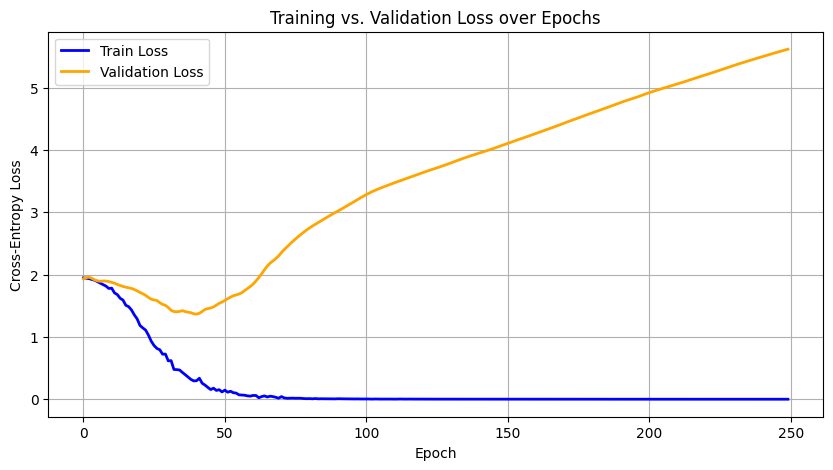

In [102]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', color='blue', linewidth=2)
plt.plot(val_losses, label='Validation Loss', color='orange', linewidth=2)
plt.title('Training vs. Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.grid(True)
plt.show()

In [123]:

def test(model):
    model.eval()
    out = model(x_dense)
    out = out.squeeze(0)
    pred = out.argmax(dim=1)
    test_correct = pred[data.test_mask] == data.y[data.test_mask]
    test_acc = int(test_correct.sum()) / int(data.test_mask.sum())
    return test_acc

test_acc = test(model_gcn)
print(f'Test Accuracy: {test_acc:.4f}')

Test Accuracy: 0.7750


## GAT CONV ##

In [34]:
from torch_geometric.nn import GATConv

class GAT(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.gat1 = GATConv(dataset.num_features, 8, heads=8,dropout=0.6) 
        self.gat2 = GATConv(8*8, dataset.num_classes, heads=1, concat=False, dropout=0.6)

    def forward(self, x, edge_index):
        x = F.dropout(x, p=0.6, training=self.training)
        x = self.gat1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=0.6, training=self.training)
        x = self.gat2(x, edge_index)
        return x

model = GAT()
print(model)


GAT(
  (gat1): GATConv(1433, 8, heads=8)
  (gat2): GATConv(64, 7, heads=1)
)


In [35]:
import copy

model_gat = GAT()

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam([
    dict(params=model_gat.gat1.parameters(), weight_decay=5e-4),
    dict(params=model_gat.gat2.parameters(), weight_decay=0)   
], lr=0.005)

train_losses = []
val_losses = []

best_val_acc = 0.0
best_weights = None
best_epoch = 0

for epoch in range(250):
    loss , acc = train(model_gat, optimizer, criterion)
    
    val_los, val_acc = evaluate(model_gat,criterion)
    
    train_losses.append(loss)
    val_losses.append(val_los)  
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_weights = copy.deepcopy(model_gat.state_dict())
        best_epoch = epoch
        
    if epoch % 10 == 0:
        print(f'Epoch {epoch:>3} | Loss: {loss:.2f} | ValLoss: {val_los:.2f} | Acc: {acc*100:.2f}%')
        

model_gat.load_state_dict(best_weights)
print(f'Best validation accuracy: {best_val_acc:.4f} at epoch {best_epoch}')

TypeError: GAT.forward() missing 1 required positional argument: 'edge_index'

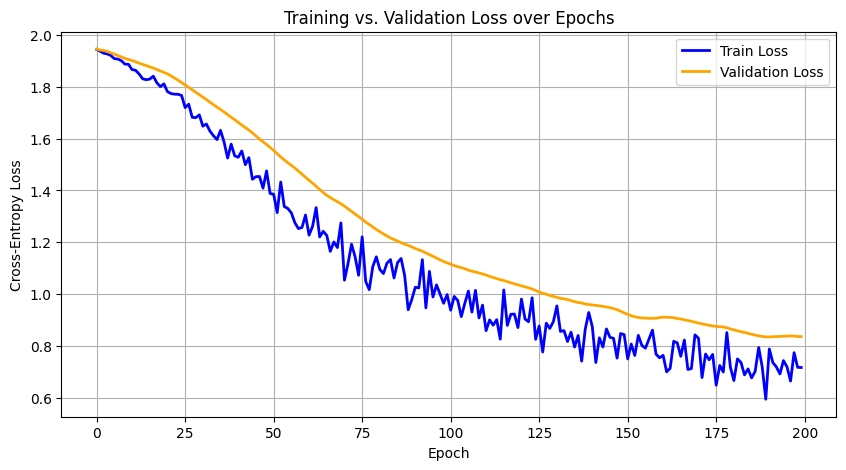

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', color='blue', linewidth=2)
plt.plot(val_losses, label='Validation Loss', color='orange', linewidth=2)
plt.title('Training vs. Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
test_acc = test(model_gat)
print(f'Test Accuracy: {test_acc:.4f}')

Test Accuracy: 0.8280


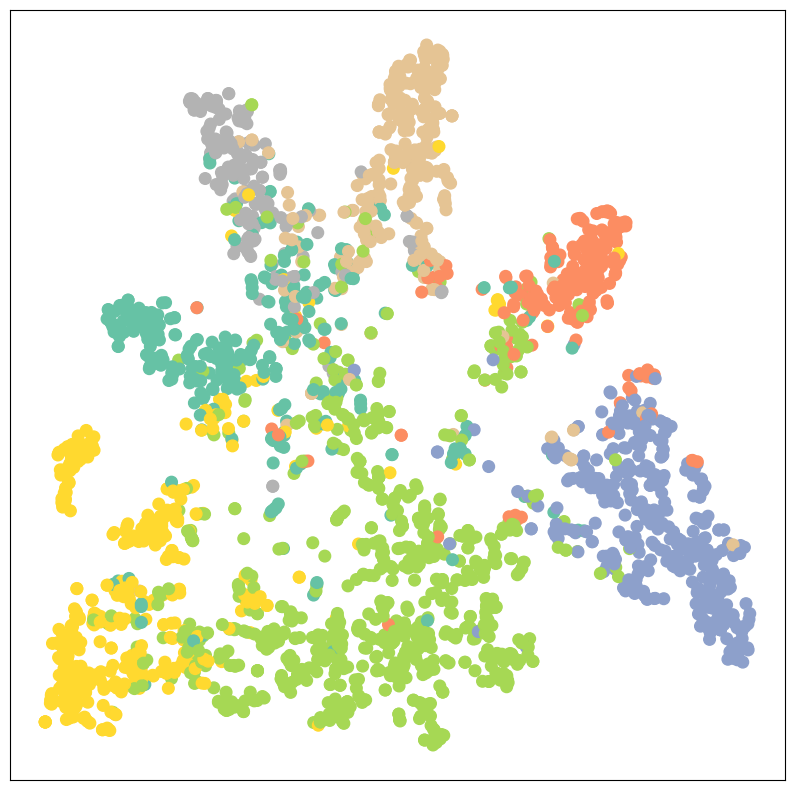

In [ ]:
model_gat.eval()

out = model_gat(data.x, data.edge_index)
visualize(out, color=data.y)